In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Now We Load The Dataset

In [93]:
df = pd.read_csv("../dataset/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

The datasets are loaded perfectly.

# Encoding Target & Features

Because machine learning models cannot understand text directly, we will use Label Encoding to convert our target column into numeric values (0, 1, and 2). Then, we will use One-Hot Encoding to convert the remaining categorical features into dummy variables.

In [95]:
le = LabelEncoder()
df["Target"] = le.fit_transform(df["Target"])

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df["Target"].value_counts())

df = pd.get_dummies(df, drop_first=True)

Class mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Target
2    2209
0    1421
1     794
Name: count, dtype: int64


We can see that the text-based categories have been successfully converted into numbers. There are 3 classes in total, so our Decision Tree model will perform multiclass classification. Finally, the remaining text features are transformed into numerical dummy variables so the model can easily process them.

# Separating features and target

In [96]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4424, 36)
Target shape: (4424,)


We can see that our dataset is successfully separated into 4,424 input features and target labels.

# Spliting the dataset

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3539, 36)
Testing data: (885, 36)


To prepare for machine learning, this data is divided into two parts, using 80% of the data (3,539 students) to train the model and saving the remaining 20% (885 students) to accurately test its performance.

# Starting Training the Baseline Model (Decision Tree)

We will now initialize the Decision Tree classifier and train the model using our training data. We set a max_depth to prevent the tree from overfitting.

In [98]:
dt_model = DecisionTreeClassifier(
    max_depth=5, 
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


# Prediction Generating

In [99]:
y_pred = dt_model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


# Calculate Accuracy

In [100]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Decision Tree Accuracy: {accuracy:.4f}")
print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%")

Decision Tree Accuracy: 0.7559
Decision Tree Accuracy: 75.59%


We can see the overall accuracy of the Decision Tree classifier on the test dataset.

# Classification Report

In [101]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.69      0.75       284
    Enrolled       0.56      0.34      0.42       159
    Graduate       0.76      0.95      0.84       442

    accuracy                           0.76       885
   macro avg       0.72      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885



# Confusion Matrix

In [102]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[195  32  57]
 [ 29  54  76]
 [ 11  11 420]]


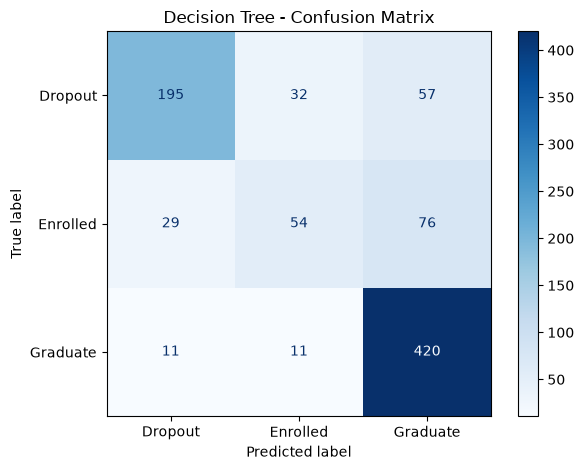

In [103]:
os.makedirs("../results/decision_tree", exist_ok=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")

plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../results/decision_tree/confusion_matrix_dt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Confusion Matrix Observation

We can see from the confusion matrix how the Decision Tree model performs across all three student outcomes. The model successfully identified the majority of **Graduate** and **Dropout** students. However, similar to the other baseline models, classifying the **Enrolled** students remains relatively challenging due to overlapping characteristics and class imbalance within the dataset.

# Feature Importance Analyze

Now we extract the feature importance scores from the trained Decision Tree model to identify which academic, financial, or demographic factors contribute the most to the prediction.

In [104]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance["Feature"] = feature_importance["Feature"].str.replace("\t", "")

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.695347
16,Tuition fees up to date,0.093462
22,Curricular units 1st sem (enrolled),0.049966
23,Curricular units 1st sem (evaluations),0.031745
28,Curricular units 2nd sem (enrolled),0.031223
35,GDP,0.013418
19,Age at enrollment,0.012386
10,Mother's occupation,0.011459
24,Curricular units 1st sem (approved),0.009676
12,Admission grade,0.009174


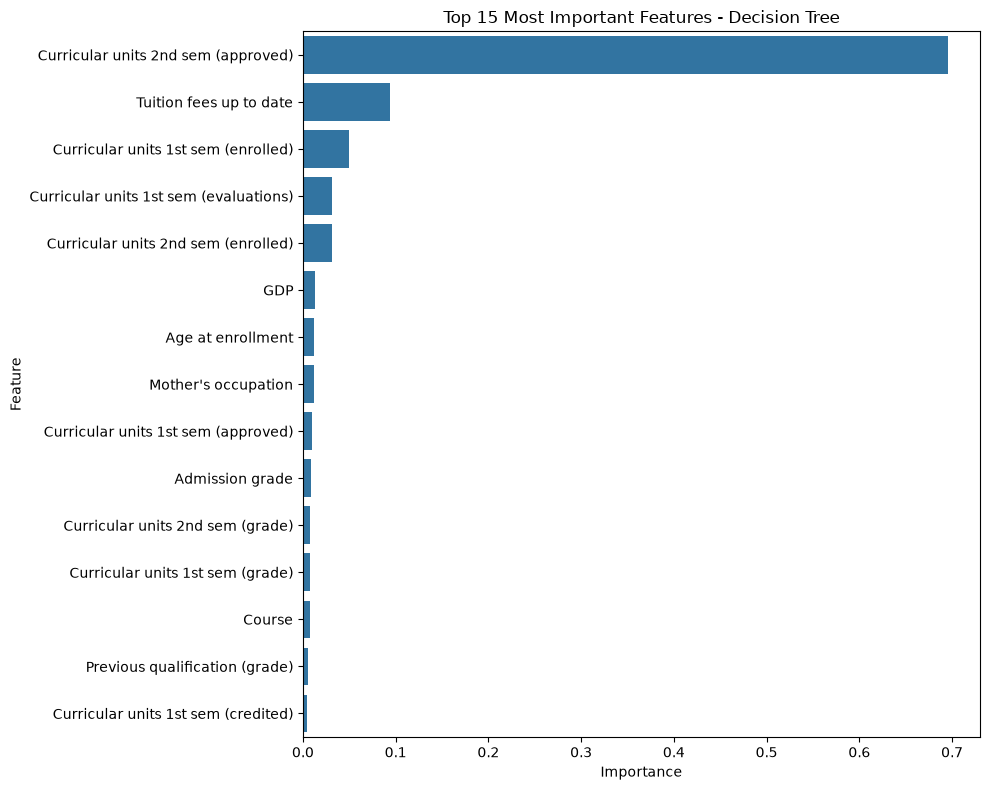

In [105]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features - Decision Tree")
plt.tight_layout()

plt.savefig(
    "../results/decision_tree/feature_importance_dt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation & Model Summary

In this notebook, we implemented a **Decision Tree** classifier to predict multiclass student outcomes (**Dropout**, **Enrolled**, and **Graduate**). After evaluating the model on the test dataset (885 records), it achieved an overall **Accuracy of 75.59%**[cite: 17].

Analyzing the class-specific performance, the model was highly effective at identifying **Graduate** students, achieving a **Precision of 0.76**, a very high **Recall of 0.95**, and an **F1-score of 0.84**[cite: 17]. For the **Dropout** class, the model also showed reliable performance with a **Precision of 0.83**, **Recall of 0.69**, and an **F1-score of 0.75**[cite: 17]. However, predicting the **Enrolled** students remains a significant challenge, yielding a **Precision of 0.56**, **Recall of 0.34**, and an **F1-score of 0.42**[cite: 17]. This drop in performance for the 'Enrolled' category is largely due to its minority representation and overlapping features with the other two classes.

Furthermore, the feature importance analysis clearly highlighted that early academic success—specifically **Curricular units 2nd sem (approved)** and **Curricular units 1st sem (enrolled)**—along with financial indicators like **Tuition fees up to date**, are the most dominant decision nodes for this model[cite: 17]. Overall, this Decision Tree model provides a solid, highly interpretable baseline that justifies our progression towards more advanced sequential models (LSTM) and granular Explainable AI (SHAP) evaluations.